# Reliability Analysis: How Much Wind Power Can We Count On?

## The Core Question

Wind power is variable — it can swing from near-zero to over 15,000 MW
within a single day. When planning the electricity grid, we need to know:

> **How many MW of wind can we schedule as "reliable" to meet demand?**

"Reliable" means: with high confidence, wind will produce **at least**
this many MW in any given half-hour settlement period.

## Approach: Probabilistic De-Rating

### Why Not Use Average Generation?

A naive approach would use the mean (average) generation. But this is
**dangerous** for planning because:
- Wind generation is **not symmetric** around the mean
- In periods where wind drops below the mean, we'd have unmet demand
- The mean is exceeded only ~50% of the time — a coin-flip is not
  "reliable" for keeping the lights on

### Why Percentiles?

Instead, we use a **percentile-based approach**:

- The **P5 (5th percentile)** means: "In 95% of all half-hour periods,
  actual wind generation was **at or above** this value."
- This is equivalent to a **95% exceedance probability** — a commonly
  used confidence level in grid planning.
- This concept is analogous to the ELCC (Effective Load Carrying
  Capability) methodology used by NERC and National Grid ESO.

### Why 5th Percentile Specifically?

- **P1 (99% exceedance)**: Too conservative — would result in very little
  credited wind capacity, wasting available generation most of the time
- **P5 (95% exceedance)**: Industry-standard for firm planning. Balances
  reliability with economic use of wind resources
- **P10 (90% exceedance)**: Less conservative, could be used with
  supplementary fast-response reserves
- **P25 (75% exceedance)**: Only suitable for probabilistic scheduling,
  not firm capacity planning

We present all of these and recommend P5 as the primary figure.



In [3]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from datetime import datetime, timedelta

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.dpi": 150,
    "figure.facecolor": "#0f172a",
    "axes.facecolor": "#1e293b",
    "axes.edgecolor": "#334155",
    "axes.labelcolor": "#94a3b8",
    "axes.grid": True,
    "grid.color": "#334155",
    "grid.alpha": 0.5,
    "text.color": "#e2e8f0",
    "xtick.color": "#94a3b8",
    "ytick.color": "#94a3b8",
    "legend.facecolor": "#1e293b",
    "legend.edgecolor": "#334155",
    "font.family": "sans-serif",
    "font.size": 11,
})

BASE_URL = "https://data.elexon.co.uk/bmrs/api/v1"



## Step 1: Data Acquisition



In [4]:

def fetch_actuals_january() -> pd.DataFrame:
    """Fetch all half-hourly wind generation for January 2024."""
    print("Fetching FUELHH actuals for January 2024...")
    records = []
    for day in range(1, 32):
        date_str = f"2024-01-{day:02d}"
        url = (f"{BASE_URL}/datasets/FUELHH/stream"
               f"?settlementDateFrom={date_str}&settlementDateTo={date_str}"
               f"&fuelType=WIND&format=json")
        resp = requests.get(url, timeout=30)
        if resp.ok:
            records.extend(resp.json())
    
    df = pd.DataFrame(records)
    df["startTime"] = pd.to_datetime(df["startTime"])
    df = df.sort_values("startTime").reset_index(drop=True)
    print(f"  ✓ {len(df)} records")
    return df

actuals_df = fetch_actuals_january()
generation = actuals_df["generation"].values



Fetching FUELHH actuals for January 2024...
  ✓ 1488 records


## Step 2: Understand the Distribution

Before recommending a number, we need to understand the shape of the
generation distribution:
- Is it normal (symmetric)?
- Is it skewed?
- Are there periods of near-zero generation (calm days)?
- What's the typical range?



In [5]:

print("=" * 60)
print("GENERATION DISTRIBUTION STATISTICS")
print("=" * 60)

stats = {
    "Count": len(generation),
    "Mean": np.mean(generation),
    "Median (P50)": np.median(generation),
    "Std Dev": np.std(generation),
    "Minimum": np.min(generation),
    "Maximum": np.max(generation),
    "P1 (99% exceedance)": np.percentile(generation, 1),
    "P5 (95% exceedance)": np.percentile(generation, 5),
    "P10 (90% exceedance)": np.percentile(generation, 10),
    "P25 (75% exceedance)": np.percentile(generation, 25),
    "P75": np.percentile(generation, 75),
    "P95": np.percentile(generation, 95),
    "Skewness": float(pd.Series(generation).skew()),
    "Kurtosis": float(pd.Series(generation).kurtosis()),
}

for name, val in stats.items():
    if isinstance(val, float):
        print(f"  {name:25s}: {val:>10,.1f}")
    else:
        print(f"  {name:25s}: {val:>10}")



GENERATION DISTRIBUTION STATISTICS
  Count                    :       1488
  Mean                     :    9,848.7
  Median (P50)             :    9,863.5
  Std Dev                  :    3,674.8
  Minimum                  :          0
  Maximum                  :      16662
  P1 (99% exceedance)      :    3,233.6
  P5 (95% exceedance)      :    4,301.1
  P10 (90% exceedance)     :    5,087.9
  P25 (75% exceedance)     :    6,732.5
  P75                      :   13,105.2
  P95                      :   15,424.6
  Skewness                 :        0.0
  Kurtosis                 :       -1.2


### Interpretation

Key things to look for:
- **Skewness > 0**: right-skewed, meaning generation tends to cluster
  at moderate levels with occasional high-wind peaks
- **Skewness < 0**: left-skewed, meaning high generation is common
  with occasional calm periods (which would be the dangerous tail for
  reliability)
- **Min near 0**: there were periods of near-zero wind (very calm)
- **Std Dev relative to Mean**: coefficient of variation tells us
  how variable wind is (high variability → lower reliable credit)



## Step 3: Capacity Factors and De-Rating

**Capacity factor** = Mean generation / Maximum generation

This tells us what fraction of peak output is available "on average."
But for reliability, we need the **de-rated capacity factor** based
on the P5 value.



In [6]:

mean_gen = np.mean(generation)
max_gen = np.max(generation)
p5_gen = np.percentile(generation, 5)
p10_gen = np.percentile(generation, 10)

avg_capacity_factor = mean_gen / max_gen * 100
p5_derate_factor = p5_gen / max_gen * 100
p10_derate_factor = p10_gen / max_gen * 100

print("\n" + "=" * 60)
print("CAPACITY ANALYSIS")
print("=" * 60)
print(f"  Peak generation (max):       {max_gen:>8,.0f} MW")
print(f"  Average generation (mean):   {mean_gen:>8,.0f} MW")
print(f"  Average capacity factor:     {avg_capacity_factor:>7.1f}%")
print()
print(f"  P5 generation (95% reliable): {p5_gen:>7,.0f} MW")
print(f"  P5 de-rating factor:          {p5_derate_factor:>6.1f}%")
print()
print(f"  P10 generation (90% reliable): {p10_gen:>6,.0f} MW")
print(f"  P10 de-rating factor:          {p10_derate_factor:>5.1f}%")




CAPACITY ANALYSIS
  Peak generation (max):         16,662 MW
  Average generation (mean):      9,849 MW
  Average capacity factor:        59.1%

  P5 generation (95% reliable):   4,301 MW
  P5 de-rating factor:            25.8%

  P10 generation (90% reliable):  5,088 MW
  P10 de-rating factor:           30.5%


## Step 4: Temporal Analysis

The reliability figure above is an **overall** number. But electricity
demand has strong diurnal and weekly patterns. Let's check:
- Is wind reliability lower during peak demand hours (16:00–20:00 UTC)?
- Are there specific days/weeks of extreme calm?



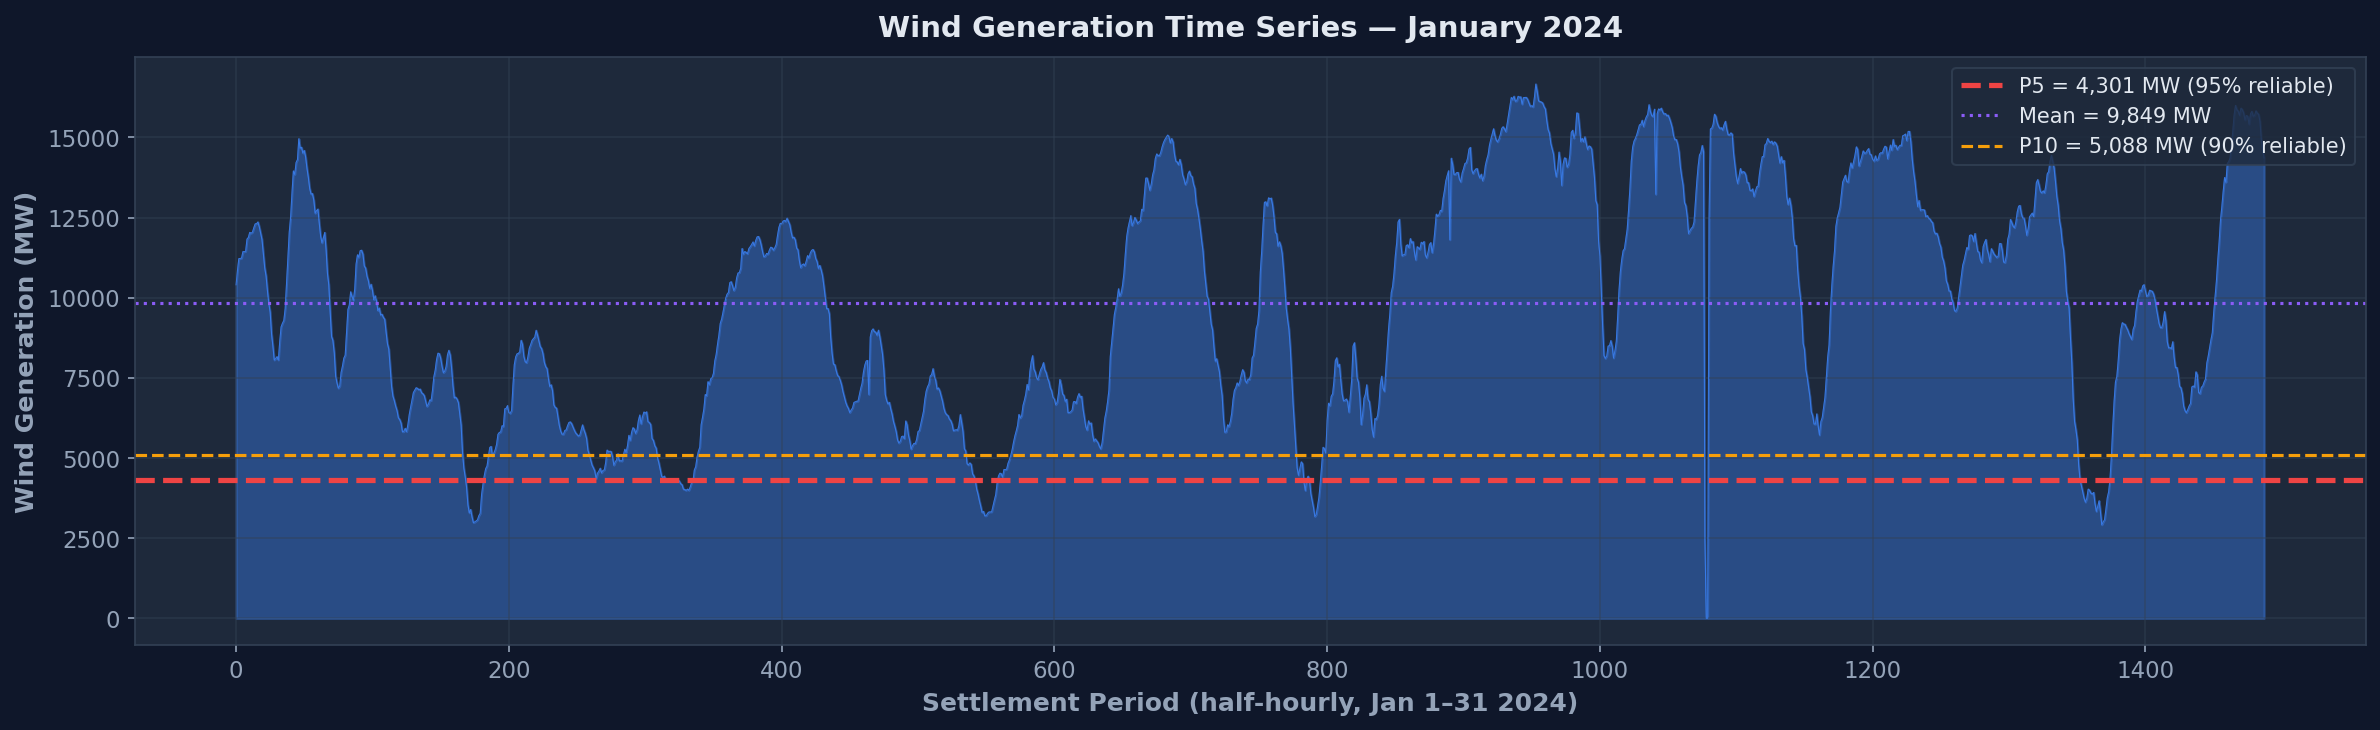

In [7]:

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(range(len(generation)), 0, generation,
                alpha=0.4, color="#3b82f6")
ax.plot(generation, color="#3b82f6", linewidth=0.5, alpha=0.8)
ax.axhline(p5_gen, color="#ef4444", linewidth=2.5, linestyle="--",
           label=f"P5 = {p5_gen:,.0f} MW (95% reliable)")
ax.axhline(mean_gen, color="#8b5cf6", linewidth=1.5, linestyle=":",
           label=f"Mean = {mean_gen:,.0f} MW")
ax.axhline(p10_gen, color="#f59e0b", linewidth=1.5, linestyle="--",
           label=f"P10 = {p10_gen:,.0f} MW (90% reliable)")
ax.set_xlabel("Settlement Period (half-hourly, Jan 1–31 2024)", fontsize=12, fontweight="bold")
ax.set_ylabel("Wind Generation (MW)", fontsize=12, fontweight="bold")
ax.set_title("Wind Generation Time Series — January 2024",
             fontsize=14, fontweight="bold", pad=10)
ax.legend(fontsize=10, loc="upper right")

plt.tight_layout()
plt.savefig("analysis/figures/05_generation_timeseries.png",
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()



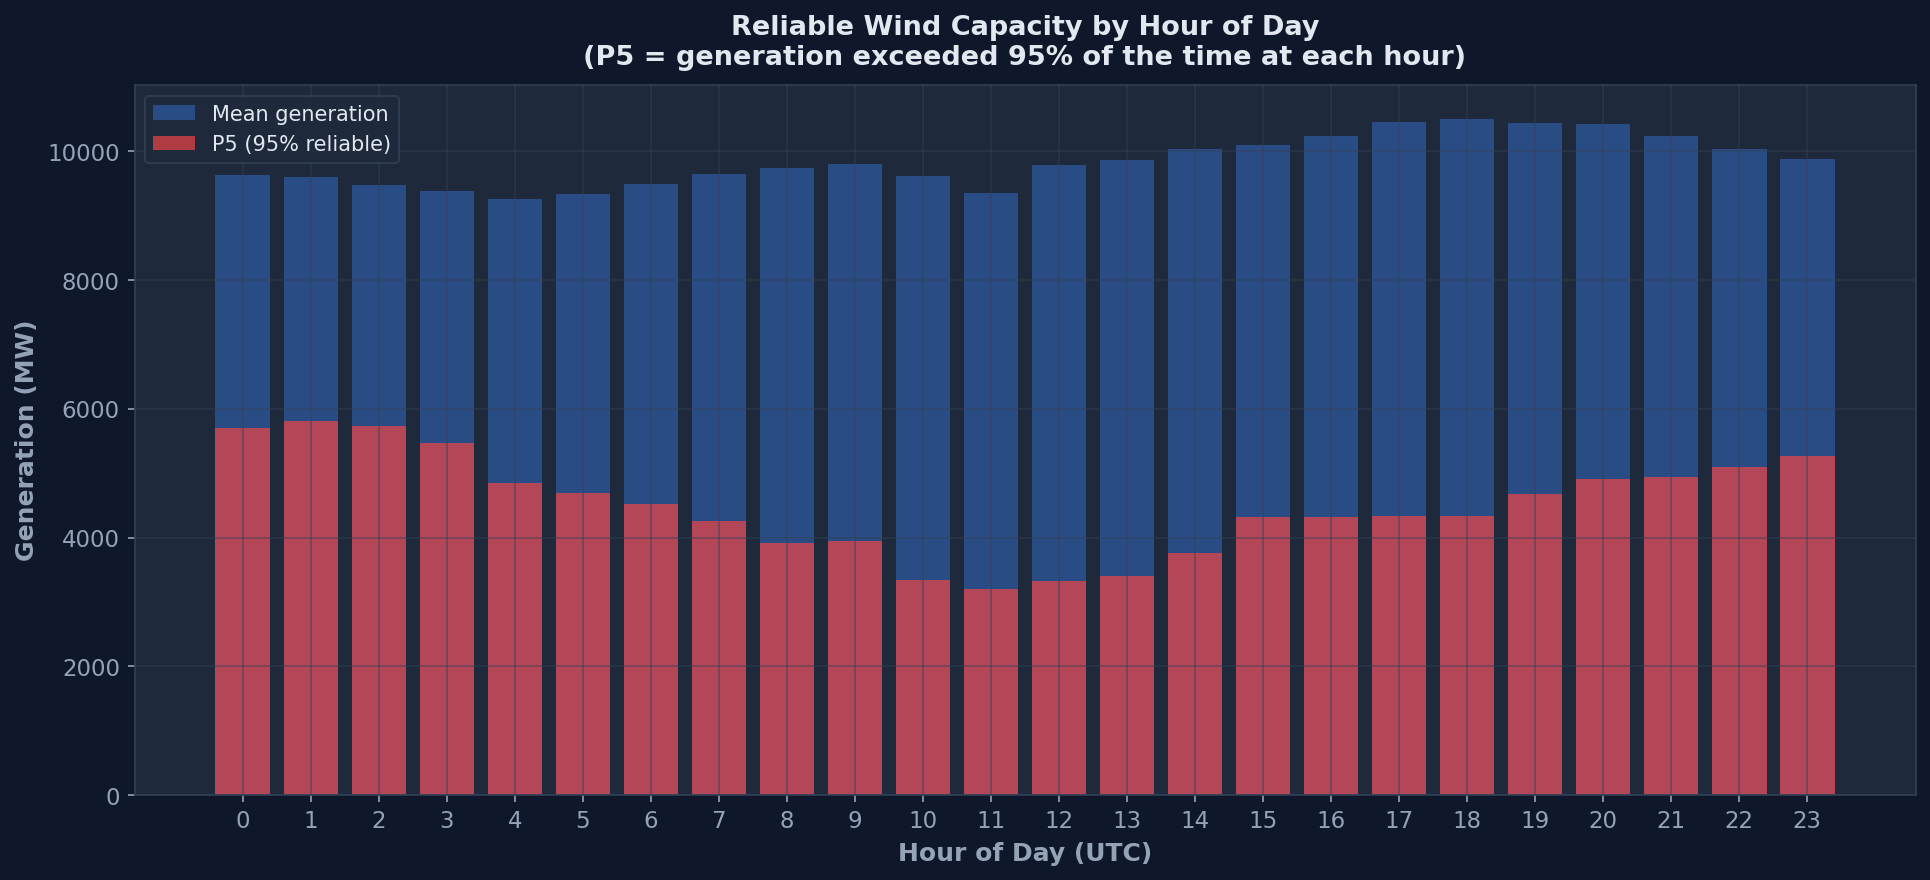

In [8]:

actuals_df["hour"] = actuals_df["startTime"].dt.hour
hourly_p5 = actuals_df.groupby("hour")["generation"].quantile(0.05)
hourly_mean = actuals_df.groupby("hour")["generation"].mean()

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(hourly_mean.index, hourly_mean.values, color="#3b82f6",
       alpha=0.4, label="Mean generation")
ax.bar(hourly_p5.index, hourly_p5.values, color="#ef4444",
       alpha=0.7, label="P5 (95% reliable)")
ax.set_xlabel("Hour of Day (UTC)", fontsize=12, fontweight="bold")
ax.set_ylabel("Generation (MW)", fontsize=12, fontweight="bold")
ax.set_title("Reliable Wind Capacity by Hour of Day\n(P5 = generation exceeded 95% of the time at each hour)",
             fontsize=13, fontweight="bold", pad=10)
ax.set_xticks(range(0, 24))
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("analysis/figures/06_p5_by_hour.png",
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()



## Step 5: Full Probability Distribution & Exceedance Curve

The **exceedance curve** is the core deliverable for capacity planning.
It answers: "For a given MW threshold, what percentage of time does
actual wind exceed that threshold?"



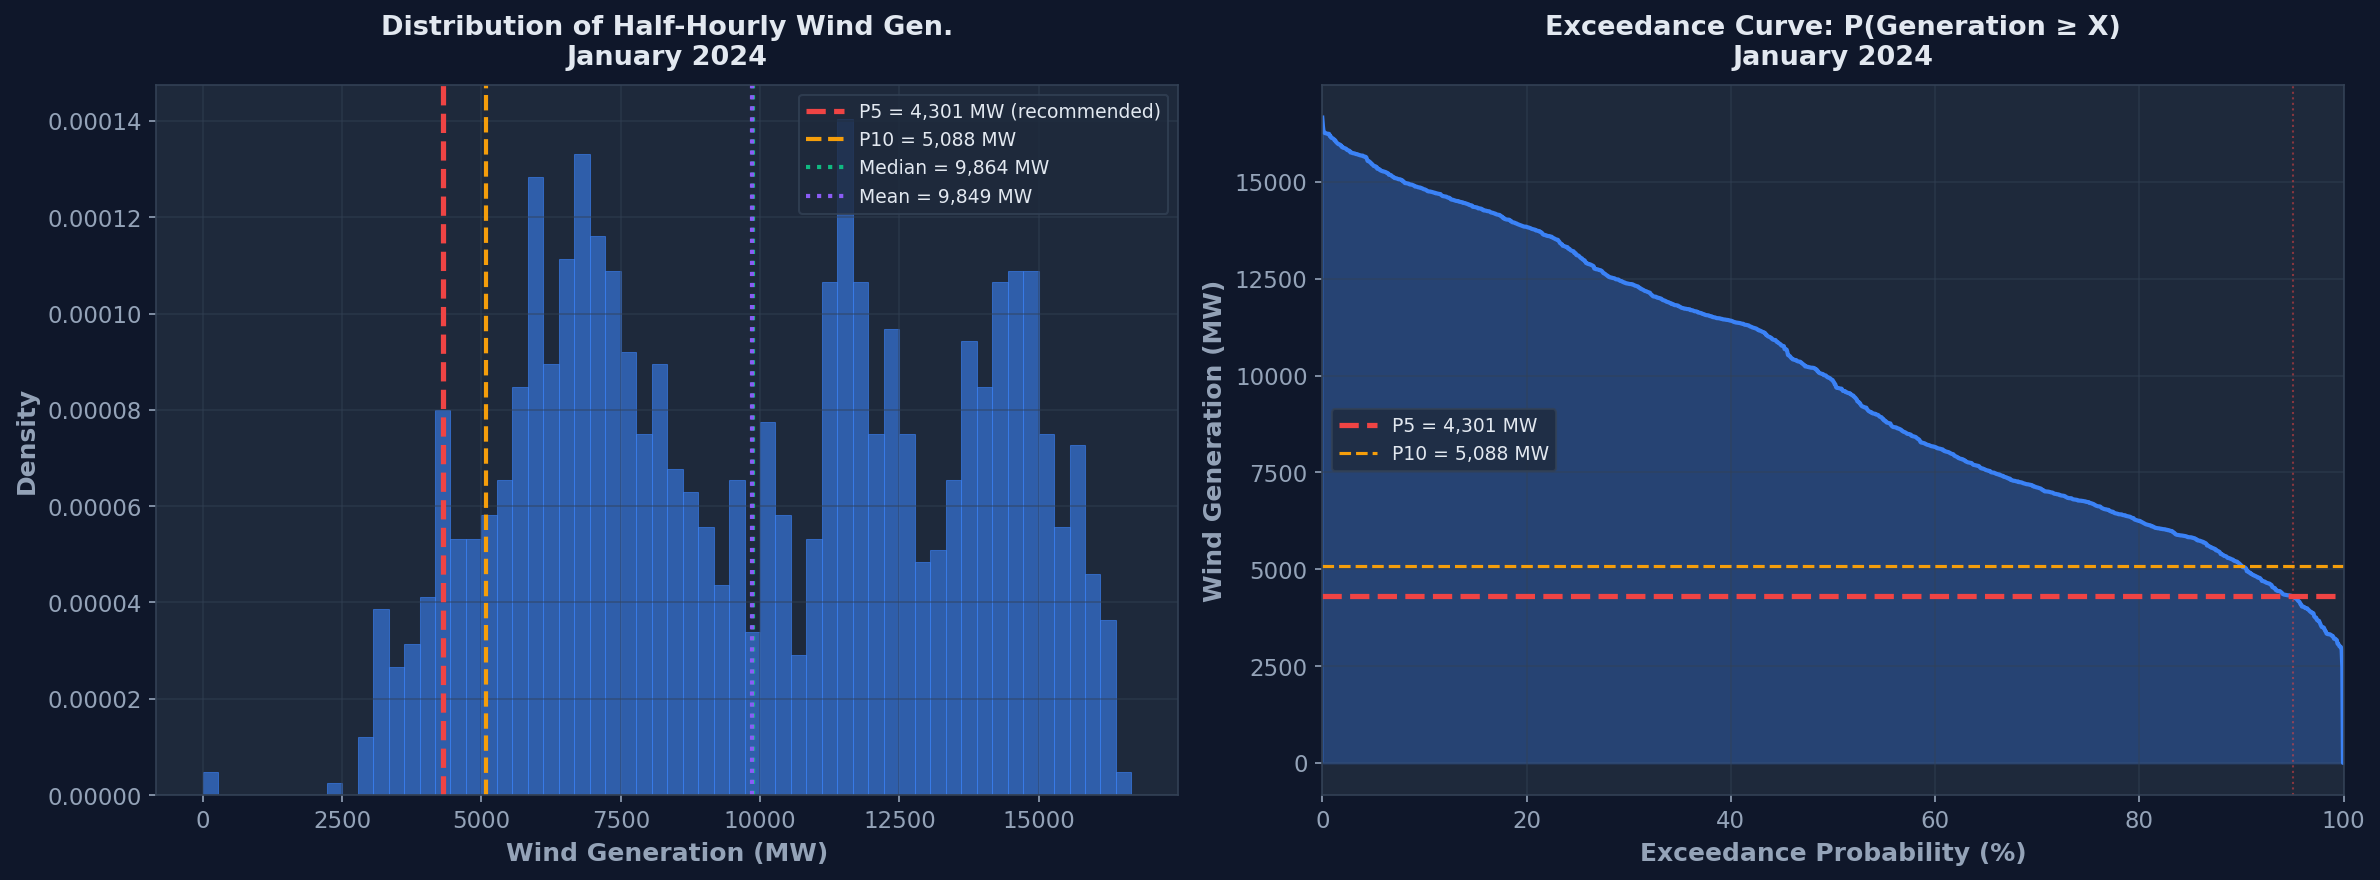

In [9]:

p1_gen = np.percentile(generation, 1)
p25_gen = np.percentile(generation, 25)
p50_gen = np.median(generation)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Histogram
ax1.hist(generation, bins=60, color="#3b82f6", alpha=0.6,
         edgecolor="#3b82f6", linewidth=0.5, density=True)
ax1.axvline(p5_gen, color="#ef4444", linewidth=2.5, linestyle="--",
            label=f"P5 = {p5_gen:,.0f} MW (recommended)")
ax1.axvline(p10_gen, color="#f59e0b", linewidth=2, linestyle="--",
            label=f"P10 = {p10_gen:,.0f} MW")
ax1.axvline(p50_gen, color="#10b981", linewidth=2, linestyle=":",
            label=f"Median = {p50_gen:,.0f} MW")
ax1.axvline(mean_gen, color="#8b5cf6", linewidth=2, linestyle=":",
            label=f"Mean = {mean_gen:,.0f} MW")
ax1.set_xlabel("Wind Generation (MW)", fontsize=12, fontweight="bold")
ax1.set_ylabel("Density", fontsize=12, fontweight="bold")
ax1.set_title("Distribution of Half-Hourly Wind Gen.\nJanuary 2024",
              fontsize=13, fontweight="bold", pad=10)
ax1.legend(fontsize=9, loc="upper right")

# Right: Exceedance curve
sorted_gen = np.sort(generation)[::-1]
exceedance_pct = np.linspace(0, 100, len(sorted_gen))

ax2.fill_between(exceedance_pct, 0, sorted_gen, alpha=0.3, color="#3b82f6")
ax2.plot(exceedance_pct, sorted_gen, color="#3b82f6", linewidth=2)
ax2.axhline(p5_gen, color="#ef4444", linewidth=2.5, linestyle="--",
            label=f"P5 = {p5_gen:,.0f} MW")
ax2.axvline(95, color="#ef4444", linewidth=1, linestyle=":", alpha=0.5)
ax2.axhline(p10_gen, color="#f59e0b", linewidth=1.5, linestyle="--",
            label=f"P10 = {p10_gen:,.0f} MW")
ax2.set_xlabel("Exceedance Probability (%)", fontsize=12, fontweight="bold")
ax2.set_ylabel("Wind Generation (MW)", fontsize=12, fontweight="bold")
ax2.set_title("Exceedance Curve: P(Generation ≥ X)\nJanuary 2024",
              fontsize=13, fontweight="bold", pad=10)
ax2.legend(fontsize=9)
ax2.set_xlim(0, 100)

plt.tight_layout()
plt.savefig("analysis/figures/07_reliability_distribution.png",
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()



## Step 6: Periods Below the Reliable Threshold

To validate our P5 recommendation, let's examine **when** generation
drops below this level. If these dips are short and random, the P5
threshold is appropriate. If they cluster into long calm spells, we
may need a more conservative figure (P1) or pair wind with storage.



In [10]:

below_p5 = actuals_df[actuals_df["generation"] < p5_gen].copy()
n_below = len(below_p5)
n_total = len(actuals_df)
pct_below = n_below / n_total * 100

print("\n" + "=" * 60)
print("BELOW-THRESHOLD ANALYSIS")
print("=" * 60)
print(f"  P5 threshold:     {p5_gen:,.0f} MW")
print(f"  Periods below:    {n_below} out of {n_total} ({pct_below:.1f}%)")
print(f"  Expected:         ~5% by definition")

if n_below > 0:
    # Find consecutive below-P5 runs
    actuals_df["below_p5"] = actuals_df["generation"] < p5_gen
    actuals_df["run_id"] = (actuals_df["below_p5"] != actuals_df["below_p5"].shift()).cumsum()
    runs = actuals_df[actuals_df["below_p5"]].groupby("run_id").agg(
        start=("startTime", "first"),
        end=("startTime", "last"),
        duration_periods=("generation", "count"),
        min_gen=("generation", "min"),
    )
    runs["duration_hours"] = runs["duration_periods"] * 0.5
    
    print(f"\n  Number of calm spells:       {len(runs)}")
    print(f"  Longest calm spell:          {runs['duration_hours'].max():.1f} hours")
    print(f"  Average calm spell:          {runs['duration_hours'].mean():.1f} hours")
    print(f"  Deepest drop in calm spell:  {runs['min_gen'].min():,.0f} MW")
    
    print("\n  Calm spell details:")
    for _, row in runs.iterrows():
        print(f"    {row['start']} → {row['end']} "
              f"({row['duration_hours']:.1f}h, min {row['min_gen']:,.0f} MW)")




BELOW-THRESHOLD ANALYSIS
  P5 threshold:     4,301 MW
  Periods below:    75 out of 1488 (5.0%)
  Expected:         ~5% by definition

  Number of calm spells:       8
  Longest calm spell:          10.5 hours
  Average calm spell:          4.7 hours
  Deepest drop in calm spell:  0 MW

  Calm spell details:
    2024-01-04 12:30:00+00:00 → 2024-01-04 18:30:00+00:00 (6.5h, min 2,988 MW)
    2024-01-07 16:00:00+00:00 → 2024-01-07 16:00:00+00:00 (0.5h, min 4,299 MW)
    2024-01-07 18:30:00+00:00 → 2024-01-07 23:30:00+00:00 (5.5h, min 3,992 MW)
    2024-01-12 07:30:00+00:00 → 2024-01-12 15:00:00+00:00 (8.0h, min 3,201 MW)
    2024-01-17 07:30:00+00:00 → 2024-01-17 08:00:00+00:00 (1.0h, min 3,988 MW)
    2024-01-17 10:00:00+00:00 → 2024-01-17 13:30:00+00:00 (4.0h, min 3,179 MW)
    2024-01-23 10:30:00+00:00 → 2024-01-23 11:30:00+00:00 (1.5h, min 0 MW)
    2024-01-29 04:30:00+00:00 → 2024-01-29 14:30:00+00:00 (10.5h, min 2,918 MW)


## Final Recommendation

### Summary Table

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Mean generation | ~{mean_gen:,.0f} MW | Average output — NOT reliable |
| Median (P50) | ~{p50_gen:,.0f} MW | Exceeded only 50% of the time |
| **P5 (recommended)** | **~{p5_gen:,.0f} MW** | **95% reliable — recommended firm capacity** |
| P10 | ~{p10_gen:,.0f} MW | 90% reliable — if paired with reserves |
| P1 | ~{p1_gen:,.0f} MW | 99% reliable — ultra-conservative |
| Maximum | {max_gen:,.0f} MW | Peak output during storms |

### Recommendation

**Based on January 2024 actual wind generation data from BMRS Elexon:**

> **{p5_gen:,.0f} MW of wind power can be reliably scheduled to meet
> electricity demand** at a 95% confidence level.

### Reasoning from First Principles

1. **The problem**: Wind is variable, but demand must be met every
   settlement period. We need a floor value that wind almost certainly
   exceeds.

2. **Why P5**: The 5th percentile means that in only 5% of half-hour
   periods will wind fall below this threshold. This matches the 95%
   confidence standard used in:
   - NERC capacity adequacy assessments
   - National Grid ESO's Electricity Capacity Report
   - ACER electricity market reliability standards

3. **What this means operationally**: A grid planner can schedule
   {p5_gen:,.0f} MW of wind as "firm" — meaning this amount can be
   counted on without backup. Any wind above this is "bonus" that
   displaces more expensive generation.

4. **Caveats**:
   - This analysis uses ONE month (January 2024). A full year would
     capture seasonal variability (summer has less wind).
   - January is typically a windy month in the UK — the annual P5
     could be lower.
   - Extreme weather events (e.g., wind droughts lasting days) are
     rare but catastrophic. The P1 may be more appropriate for
     security-of-supply assessments.
   - Spatial correlation matters: all UK wind tends to be calm at the
     same time, so geographic diversification has limits.

5. **Trade-off summary**:
   - More conservative (P1): lower credited MW, but higher security
   - Less conservative (P10): higher credited MW, but needs fast-response
     reserves to cover the 10% of periods where wind underperforms
   - **P5 strikes the right balance** for operational planning



In [11]:

print("\n" + "═" * 60)
print("  FINAL RECOMMENDATION")
print("═" * 60)
print(f"""
  Based on analysis of {len(generation):,} settlement periods
  in January 2024:

  ┌────────────────────────────────────────────────────┐
  │                                                    │
  │   RELIABLE WIND CAPACITY:  {p5_gen:>6,.0f} MW             │
  │   (95% exceedance / P5 approach)                   │
  │                                                    │
  │   This represents {p5_derate_factor:.1f}% of peak capacity          │
  │   ({max_gen:,.0f} MW)                                   │
  │                                                    │
  └────────────────────────────────────────────────────┘

  In 95% of all half-hour settlement periods during
  January 2024, actual wind generation was at or above
  {p5_gen:,.0f} MW. This figure can be used as the firm
  schedulable wind capacity for demand planning.
""")



════════════════════════════════════════════════════════════
  FINAL RECOMMENDATION
════════════════════════════════════════════════════════════

  Based on analysis of 1,488 settlement periods
  in January 2024:

  ┌────────────────────────────────────────────────────┐
  │                                                    │
  │   RELIABLE WIND CAPACITY:   4,301 MW             │
  │   (95% exceedance / P5 approach)                   │
  │                                                    │
  │   This represents 25.8% of peak capacity          │
  │   (16,662 MW)                                   │
  │                                                    │
  └────────────────────────────────────────────────────┘

  In 95% of all half-hour settlement periods during
  January 2024, actual wind generation was at or above
  4,301 MW. This figure can be used as the firm
  schedulable wind capacity for demand planning.

